## Setup

In [1]:
import torch
print(torch.__version__)
#import torchvision
#import torch.nn as nn

import os
import sys
import time

import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.gridspec as gridspec

from data_loader import get_train_val_loader, get_test_loader
from autoencoder_helpers import *
from modules import *

#GPU/CUDA setup
if torch.cuda.is_available():
    print("CUDA enabled!")
    device = torch.device('cuda:0')  # You can specify the index of the CUDA device you want to use
    os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # Specify the index of the GPU(s) you want to use
else:
    print("CUDA not available. Using CPU.")
    device = torch.device('cpu')
    
data_folder = 'data'
batch_size = 250
n_workers = 0
random_seed = 0

# download MNIST data
test_loader = get_test_loader(data_folder, batch_size, shuffle=True, num_workers=n_workers, pin_memory=True)

# download MNIST data
train_loader, val_loader = get_train_val_loader(data_folder, batch_size, random_seed, augment=False, val_size=0.2,
                           shuffle=True, show_sample=False, num_workers=0, pin_memory=True)

2.2.0+cpu
CUDA not available. Using CPU.


# Test and look inside the model on MNIST data

Load the model

In [5]:
paths = {"B30": "saved_model\mnist_model\mnist_cae_balanced_clstsep_1500_0.002_250_True_0.0_20_1_1_1_1.0_0.0_30_4_32_1\mnist_cae00750.pth",
         "S30": "saved_model\mnist_model\mnist_cae_standard_default_1500_0.002_250_False_0.5_20_1_1_1_0.8_0.2_30_4_32_1\mnist_cae00750.pth",
         "S15": "saved_model\mnist_model\mnist_cae_standard_default_1500_0.002_250_False_0.5_20_1_1_1_0.8_0.2_15_4_32_1\mnist_cae00750.pth",
         "RS30": "saved_model\mnist_model\mnist_cae_adversarial_standard_default_pdglinf_ce_20_0.3_0.02_True_1500_0.002_250_False_0.5_20_1_1_1_0.8_0.2_1.0_30_4_32_1\mnist_cae_adv00750.pth",
         "RB30": "saved_model\mnist_model\mnist_cae_adversarial_balanced_clstsep_pdglinf_ce_20_0.3_0.02_True_800_0.002_250_True_0.0_20_1_1_1_1.0_0.0_1.0_30_4_32_1\mnist_cae_adv00750.pth",
         "FTB30n": "saved_model\mnist_model\mnist_cae_FT_30_nothing_pdglinf_ce_20_0.3_0.02_True_20_0.002_250_20_1_1_1_1.0_0.0_1\mnist_cae_adv00020.pth",
         "FTB30a": "saved_model\mnist_model\mnist_cae_FT_30_autoencoder_pdglinf_ce_20_0.3_0.02_True_20_0.002_250_20_1_1_1_1.0_0.0_1\mnist_cae_adv00020.pth",
         "FTB30p": "saved_model\mnist_model\mnist_cae_FT_30_prototypes_pdglinf_ce_20_0.3_0.02_True_20_0.002_250_20_1_1_1_1.0_0.0_1\mnist_cae_adv00020.pth",
         "B30-FT-E": "tfg_models/B30/B30-FT-E/seed=1/checkpoints/B30_B30-FT-E_seed1_best_val_adv_acc.pth"}

s15 = torch.load(paths["S15"])
s30 = torch.load(paths["S30"])
b30 = torch.load(paths["B30"])
#rs30 = torch.load(paths["RS30"])
# rb30 = torch.load(paths["RB30"])
# ftb30n = torch.load(paths["FTB30n"])
# ftb30a = torch.load(paths["FTB30a"])
# ftb30p = torch.load(paths["FTB30p"])
b30_ft_e = torch.load(paths["B30"], map_location=device, weights_only=False)
state = torch.load(paths["B30-FT-E"], map_location=device)
b30_ft_e.load_state_dict(state["model_state"])

s15.to(device)
s30.to(device)
b30.to(device)
# rs30.to(device)
# rb30.to(device)
# ftb30a.to(device)
# ftb30n.to(device)
# ftb30p.to(device)
b30_ft_e.to(device)

print("MODELS LOADED")

MODELS LOADED


In [14]:
model1 = b30_ft_e
model2 = b30

In [15]:
n_classes1 = model1.fc.linear.weight.size(0)
n_prototypes1 = model1.fc.linear.weight.size(1)
n_classes2 = model2.fc.linear.weight.size(0)
n_prototypes2 = model2.fc.linear.weight.size(1)
input_height = 28         # MNIST data input shape
input_width = input_height
print(f"Model 1: {n_classes1} classes, {n_prototypes1} prototypes")
print(f"Model 2: {n_classes2} classes, {n_prototypes2} prototypes")


Model 1: 10 classes, 30 prototypes
Model 2: 10 classes, 30 prototypes


Show model prototypes

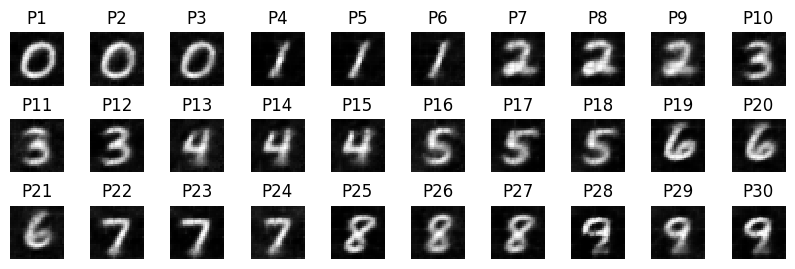

In [16]:
# visualize the prototype images
prototype_distances = model1.prototype_layer.prototype_distances
prototype_imgs = model1.decoder(prototype_distances.reshape((-1,10,2,2))).detach().cpu()

n_cols = 10
n_rows = n_prototypes1 // n_cols + 1 if n_prototypes1 % n_cols != 0 else n_prototypes1 // n_cols
g, b = plt.subplots(n_rows, n_cols, figsize=(n_cols, n_rows))

# Ajuste del espacio entre subgráficos
plt.subplots_adjust(wspace=0.5, hspace=0.5)

for i in range(n_rows):
    for j in range(n_cols):
        if i*n_cols + j < n_prototypes1:
            b[i][j].imshow(prototype_imgs[i*n_cols + j].reshape(input_height, input_width),
                            cmap='gray',
                            interpolation='none')
            b[i][j].axis('off')
            b[i][j].set_title(f'P{i*n_cols + j + 1}')
plt.show()

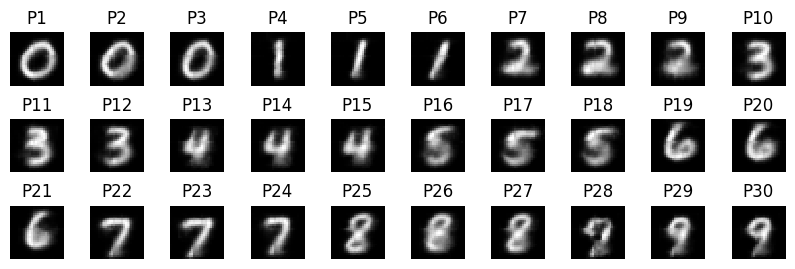

In [17]:
# visualize the prototype images
prototype_distances = model2.prototype_layer.prototype_distances
prototype_imgs = model2.decoder(prototype_distances.reshape((-1,10,2,2))).detach().cpu()

n_cols = 10
n_rows = n_prototypes2 // n_cols + 1 if n_prototypes2 % n_cols != 0 else n_prototypes2 // n_cols
g, b = plt.subplots(n_rows, n_cols, figsize=(n_cols, n_rows))

# Ajuste del espacio entre subgráficos
plt.subplots_adjust(wspace=0.5, hspace=0.5)

for i in range(n_rows):
    for j in range(n_cols):
        if i*n_cols + j < n_prototypes2:
            b[i][j].imshow(prototype_imgs[i*n_cols + j].reshape(input_height, input_width),
                            cmap='gray',
                            interpolation='none')
            b[i][j].axis('off')
            b[i][j].set_title(f'P{i*n_cols + j + 1}')
plt.show()

Decoding

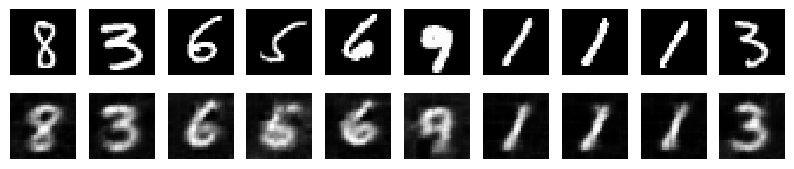

In [19]:
# Apply encoding and decoding over a small subset of the training set
batch_x = []
for batch in train_loader:
    batch_x = batch[0].to(device)
    break

examples_to_show = 10

encoded = model1.encoder.forward(batch_x[:examples_to_show])
decoded = model1.decoder.forward(encoded)

decoded = decoded.detach().cpu()
imgs = batch_x.detach().cpu()

# Compare original images to their reconstructions
f, a = plt.subplots(2, examples_to_show, figsize=(examples_to_show, 2))
for i in range(examples_to_show):
    a[0][i].imshow(imgs[i].reshape(input_height, input_width),
                   cmap='gray',
                   interpolation='none')
    a[0][i].axis('off')
    a[1][i].imshow(decoded[i].reshape(input_height, input_width), 
                   cmap='gray',
                   interpolation='none')
    a[1][i].axis('off')
                
plt.show()

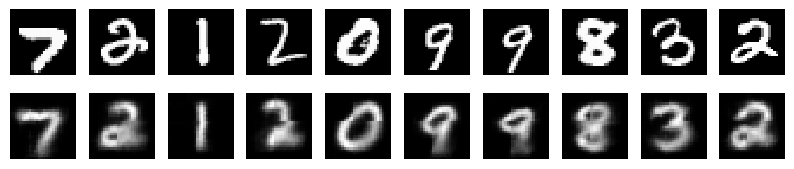

In [20]:
# Apply encoding and decoding over a small subset of the training set
batch_x = []
for batch in train_loader:
    batch_x = batch[0].to(device)
    break

examples_to_show = 10

encoded = model2.encoder.forward(batch_x[:examples_to_show])
decoded = model2.decoder.forward(encoded)

decoded = decoded.detach().cpu()
imgs = batch_x.detach().cpu()

# Compare original images to their reconstructions
f, a = plt.subplots(2, examples_to_show, figsize=(examples_to_show, 2))
for i in range(examples_to_show):
    a[0][i].imshow(imgs[i].reshape(input_height, input_width),
                   cmap='gray',
                   interpolation='none')
    a[0][i].axis('off')
    a[1][i].imshow(decoded[i].reshape(input_height, input_width), 
                   cmap='gray',
                   interpolation='none')
    a[1][i].axis('off')
                
plt.show()

Show model fc weights

In [21]:
rows = [f"P{i+1}" for i in range(n_prototypes1)]
transposed_weights = model1.fc.linear.weight.T.cpu().detach().numpy()    
df_weights = pd.DataFrame(transposed_weights, columns=range(n_classes2), index=rows)

# Find the minimum value of each row
min_values = df_weights.min(axis=1)

# Highlight the minimum values in red
def highlight_min(s):
    is_min = s == s.min()
    return ['color: red' if v else '' for v in is_min]

# Apply the highlight_min function to the DataFrame
df_highlighted = df_weights.style.apply(highlight_min, axis=1)

df_highlighted


,0,1,2,3,4,5,6,7,8,9
P1,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P2,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P3,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P4,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P5,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P6,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P7,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P8,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P9,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P10,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [23]:
rows = [f"P{i+1}" for i in range(n_prototypes2)]
transposed_weights = model2.fc.linear.weight.T.cpu().detach().numpy()    
df_weights = pd.DataFrame(transposed_weights, columns=range(n_classes2), index=rows)

# Find the minimum value of each row
min_values = df_weights.min(axis=1)

# Highlight the minimum values in red
def highlight_min(s):
    is_min = s == s.min()
    return ['color: red' if v else '' for v in is_min]

# Apply the highlight_min function to the DataFrame
df_highlighted = df_weights.style.apply(highlight_min, axis=1)

df_highlighted

,0,1,2,3,4,5,6,7,8,9
P1,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P2,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P3,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P4,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P5,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P6,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P7,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P8,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P9,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
P10,0.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
